<a href="https://colab.research.google.com/github/zaarakhan-dev/advanced-machine-learning-experiments/blob/main/exp_4_decision-tree_mushroom-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementing Decision Tree Classifier using ID3(and Entropy).
### taking dataset from kaggle

### 1. Import Necessary Libraries
Load essential libraries for data manipulation, tree visualization, model training, and performance evaluation metrics.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [33]:
df = pd.read_csv("/content/mushrooms.csv")
# 'veil-type' only has 1 unique value ('p'), which provides zero information gain
df = df.drop(columns=['veil-type'])
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g


### 3. Encode Categorical Variables
Convert categorical string labels across all attributes into numerical representations using `LabelEncoder`.
* Target mapping: `e` = 0 (Edible), `p` = 1 (Poisonous)

In [19]:
# encode the data
en = LabelEncoder()
df = df.apply(en.fit_transform)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


### 4. Split Data into Training and Testing Sets
Separate the target label (`class`) from input features (`X`). We partition 80% for training and 20% for testing using **stratification** to preserve class distribution across both subsets.

In [20]:
X = df.drop("class", axis=1)
y = df["class"]

In [29]:
y.value_counts()

,count
class,
0,4208
1,3916


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 6499, Testing samples: 1625


### 5. Train Decision Tree Classifier
Train the model using the **Entropy** criterion (Information Gain). We constrain the tree with `max_depth=5` (pre-pruning) to prevent overfitting and ensure good generalization on unseen test samples.

In [30]:
# max_depth prevents the tree from creating an overly deep, overfitted model
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


### 6. Model Evaluation on Test Data
Evaluate model predictions on the held-out test split using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

Test Accuracy: 98.03%

Classification Report:
               precision    recall  f1-score   support

   Edible (0)       0.99      0.98      0.98       842
Poisonous (1)       0.97      0.98      0.98       783

     accuracy                           0.98      1625
    macro avg       0.98      0.98      0.98      1625
 weighted avg       0.98      0.98      0.98      1625



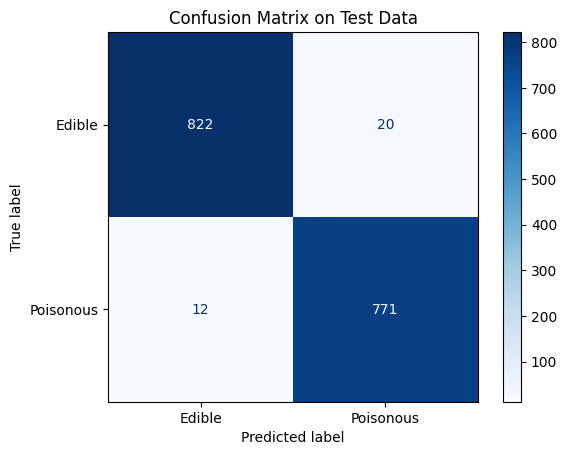

In [31]:
# Predict on the unseen test set
y_pred = model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible (0)', 'Poisonous (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible', 'Poisonous'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Data")
plt.show()

### 7. Visualize Decision Tree Structure
Plot the decision boundaries, internal split conditions, entropy values, and sample distributions at each node.

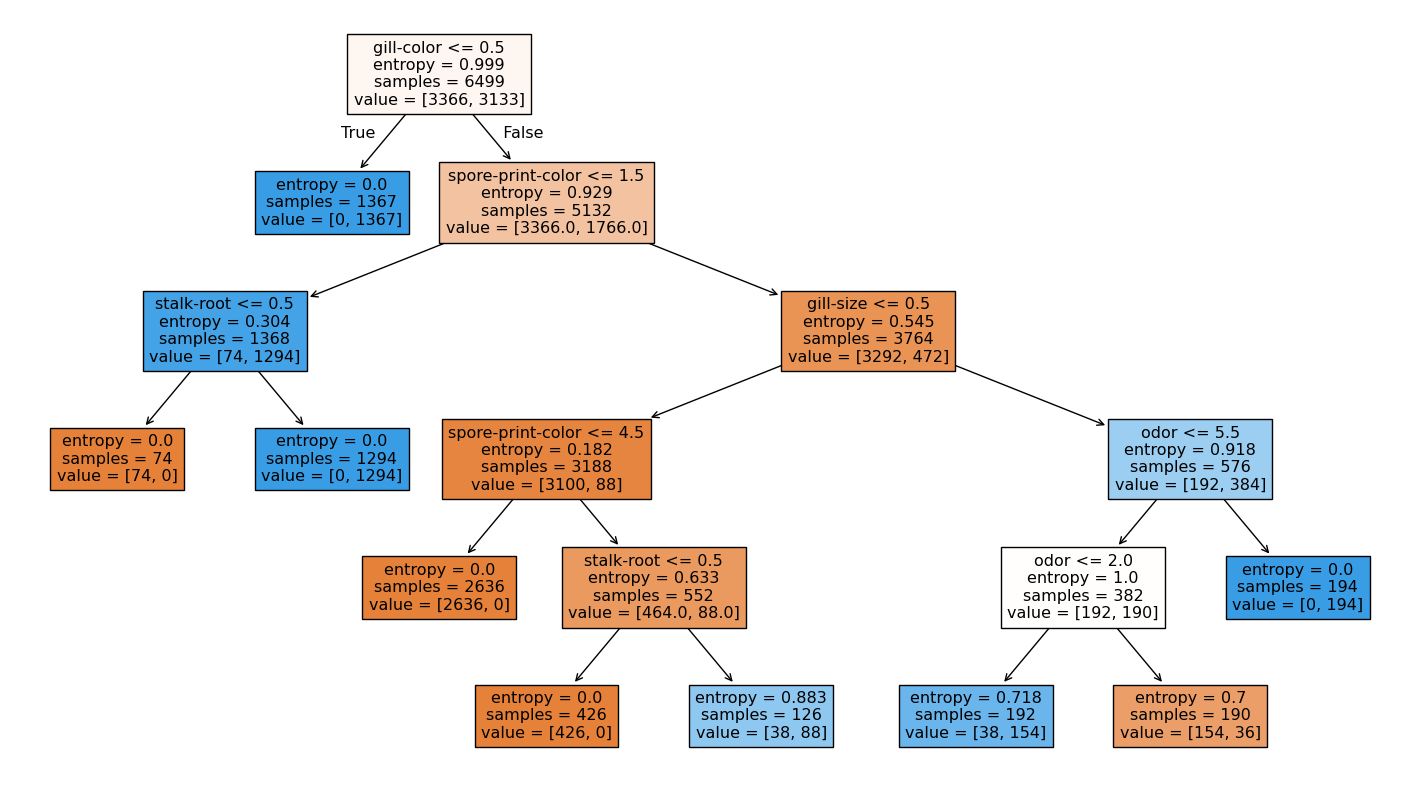

In [35]:
plt.figure(figsize=(18,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()